# Punto 3.1 — Split 80/20 y curva de score vs gamma

Generación del dataset

Shape del dataset: (300, 2)
Clases: [0 1]


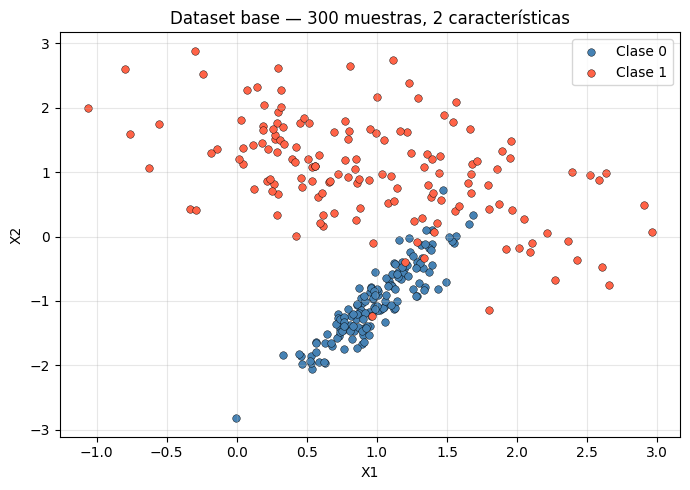

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
 
# Generar dataset de clasificacion binaria
X, y = make_classification(
    n_samples=300,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)
 
print('Shape del dataset:', X.shape)
print('Clases:', np.unique(y))

plt.figure(figsize=(7, 5))
plt.scatter(X[y==0, 0], X[y==0, 1], c='steelblue', s=30, label='Clase 0', edgecolors='k', linewidths=0.3)
plt.scatter(X[y==1, 0], X[y==1, 1], c='tomato',    s=30, label='Clase 1', edgecolors='k', linewidths=0.3)
plt.xlabel('X1') ; plt.ylabel('X2')
plt.title('Dataset base — 300 muestras, 2 características')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Train (70%), CV (10%) y Test (20%)

In [40]:
# Paso 1: separar el 20% para test
X_trainCV, X_test, y_trainCV, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
 
# Paso 2: del 80% restante, separar 10% para CV (-> 70% train, 10% CV)
# 10/80 = 0.125 del conjunto trainCV
X_train, X_cv, y_train, y_cv = train_test_split(
    X_trainCV, y_trainCV, test_size=0.125, random_state=42
)
 
print(f'Train : {len(X_train)} muestras  ({len(X_train)/len(X)*100:.0f}%)')
print(f'CV    : {len(X_cv)} muestras  ({len(X_cv)/len(X)*100:.0f}%)')
print(f'Test  : {len(X_test)} muestras  ({len(X_test)/len(X)*100:.0f}%)')


Train : 210 muestras  (70%)
CV    : 30 muestras  (10%)
Test  : 60 muestras  (20%)


Escalamiento de los datos (requerido por SVM)

In [41]:
# IMPORTANTE: el scaler se ajusta SOLO con train, nunca con CV ni test
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_cv_s    = scaler.transform(X_cv)
X_test_s  = scaler.transform(X_test)


Curva de score vs gamma (usando conjunto CV)
Se evalua el accuracy del clasificador SVM en el conjunto de entrenamiento y en el CV para distintos valores de gamma. El mejor gamma es el que maximiza el score en CV:

In [42]:
# Rango de valores de gamma a evaluar
gammas = np.logspace(-4, 2, 50)   # de 0.0001 a 100 en escala logaritmica
 
scores_train = []
scores_cv    = []
 
for gamma in gammas:
    clf = SVC(kernel='rbf', gamma=gamma, C=1.0)
    clf.fit(X_train_s, y_train)
    scores_train.append(accuracy_score(y_train, clf.predict(X_train_s)))
    scores_cv.append(accuracy_score(y_cv,    clf.predict(X_cv_s)))
 
# Mejor gamma segun CV
mejor_idx   = np.argmax(scores_cv)
mejor_gamma = gammas[mejor_idx]
print(f'Mejor gamma: {mejor_gamma:.5f}')
print(f'Score train en mejor gamma: {scores_train[mejor_idx]:.4f}')
print(f'Score CV    en mejor gamma: {scores_cv[mejor_idx]:.4f}')


Mejor gamma: 0.00010
Score train en mejor gamma: 0.9095
Score CV    en mejor gamma: 1.0000


Graficar la curva de score vs gamma

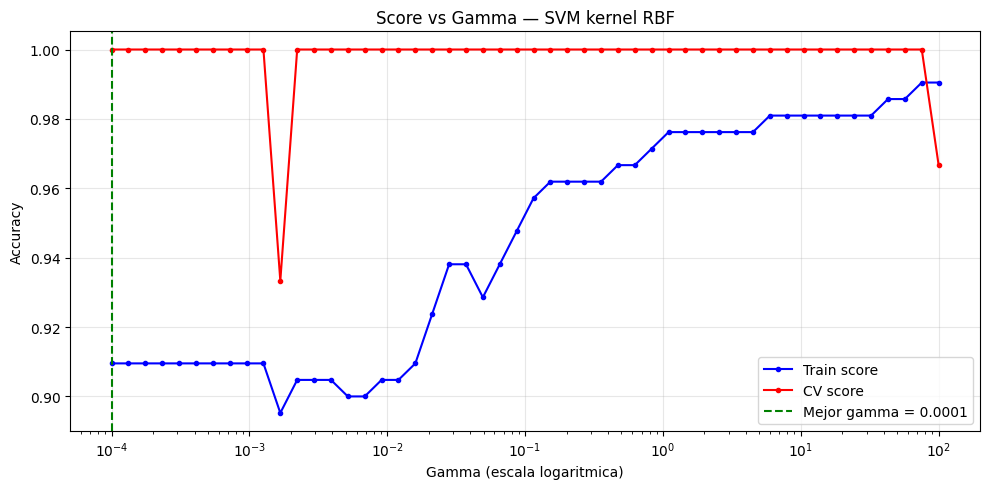

In [43]:
plt.figure(figsize=(10, 5))
plt.semilogx(gammas, scores_train, 'b-o', ms=3, label='Train score')
plt.semilogx(gammas, scores_cv,    'r-o', ms=3, label='CV score')
plt.axvline(mejor_gamma, color='green', linestyle='--',
            label=f'Mejor gamma = {mejor_gamma:.4f}')
plt.xlabel('Gamma (escala logaritmica)')
plt.ylabel('Accuracy')
plt.title('Score vs Gamma — SVM kernel RBF')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Evaluar el mejor modelo en el conjunto test

In [44]:
# Entrenar con el mejor gamma usando todos los datos de trainCV
clf_final = SVC(kernel='rbf', gamma=mejor_gamma, C=1.0)
clf_final.fit(scaler.fit_transform(X_trainCV), y_trainCV)
 
# Evaluar en test (SOLO aqui se usa el test set)
X_trainCV_s = scaler.transform(X_trainCV)
clf_final.fit(X_trainCV_s, y_trainCV)
 
# Re-escalar correctamente
scaler2 = StandardScaler().fit(X_trainCV)
clf_final2 = SVC(kernel='rbf', gamma=mejor_gamma, C=1.0)
clf_final2.fit(scaler2.transform(X_trainCV), y_trainCV)
score_test = accuracy_score(y_test, clf_final2.predict(scaler2.transform(X_test)))
print(f'Score en TEST con mejor gamma: {score_test:.4f}')


Score en TEST con mejor gamma: 0.4833


# Punto 3.2 — Curvas de aprendizaje y GridSearch

Construir curvas de aprendizaje estadistico para el modelo, comparar con sklearn, y usar GridSearchCV para encontrar los mejores hiperparametros.

Curvas de aprendizaje con sklearn learning_curve()

Las curvas de aprendizaje muestran como varía el error de train y CV a medida que se aumenta el numero de muestras de entrenamiento. Permiten diagnosticar overfitting y underfitting:

In [45]:
from sklearn.model_selection import learning_curve
 
# Usar el mejor gamma encontrado en 3.1
clf_lc = SVC(kernel='rbf', gamma=mejor_gamma, C=1.0)
 
train_sizes, train_scores, cv_scores = learning_curve(
    clf_lc,
    scaler.fit_transform(X_trainCV), y_trainCV,
    cv=5,                          # 5-fold cross validation
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy',
    n_jobs=-1
)
 
# Calcular medias y desviaciones estandar
train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
cv_mean    = cv_scores.mean(axis=1)
cv_std     = cv_scores.std(axis=1)

Graficar las curvas de aprendizaje

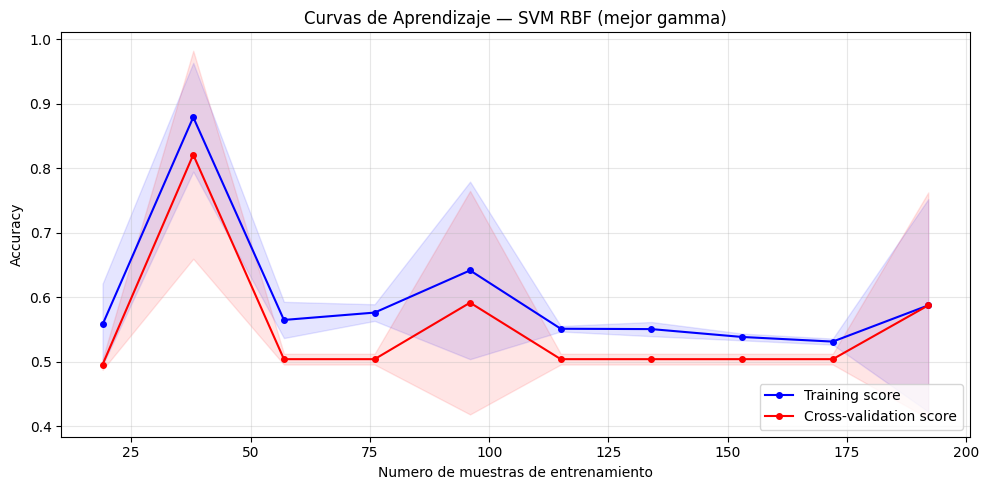

In [46]:
plt.figure(figsize=(10, 5))
 
# Banda de confianza (mean +/- std)
plt.fill_between(train_sizes, train_mean - train_std,
                 train_mean + train_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes, cv_mean - cv_std,
                 cv_mean + cv_std, alpha=0.1, color='red')
 
plt.plot(train_sizes, train_mean, 'b-o', ms=4, label='Training score')
plt.plot(train_sizes, cv_mean,    'r-o', ms=4, label='Cross-validation score')
 
plt.xlabel('Numero de muestras de entrenamiento')
plt.ylabel('Accuracy')
plt.title('Curvas de Aprendizaje — SVM RBF (mejor gamma)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


GridSearchCV — busqueda automatica del mejor gamma y C

In [47]:
from sklearn.model_selection import GridSearchCV
 
# Grilla de hiperparametros a explorar
param_grid = {
    'gamma': np.logspace(-4, 2, 10),
    'C'    : [0.1, 1, 10, 100]
}
 
grid_search = GridSearchCV(
    SVC(kernel='rbf'),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
 
X_trainCV_scaled = StandardScaler().fit_transform(X_trainCV)
grid_search.fit(X_trainCV_scaled, y_trainCV)
 
print('Mejores parametros:', grid_search.best_params_)
print('Mejor CV score:    ', grid_search.best_score_.round(4))


Fitting 5 folds for each of 40 candidates, totalling 200 fits
Mejores parametros: {'C': 100, 'gamma': np.float64(0.21544346900318823)}
Mejor CV score:     0.9792


Comparar resultado manual vs GridSearch

In [48]:
print('--- Comparacion ---')
print(f'Gamma manual (CV):   {mejor_gamma:.5f}  | Score CV: {max(scores_cv):.4f}')
print(f'Gamma GridSearch:    {grid_search.best_params_["gamma"]:.5f}  | Score CV: {grid_search.best_score_:.4f}')
 
# Evaluar el mejor modelo de GridSearch en test
scaler_gs = StandardScaler().fit(X_trainCV)
best_clf  = grid_search.best_estimator_
best_clf.fit(scaler_gs.transform(X_trainCV), y_trainCV)
score_gs_test = accuracy_score(y_test, best_clf.predict(scaler_gs.transform(X_test)))
print(f'Score TEST (GridSearch): {score_gs_test:.4f}')


--- Comparacion ---
Gamma manual (CV):   0.00010  | Score CV: 1.0000
Gamma GridSearch:    0.21544  | Score CV: 0.9792
Score TEST (GridSearch): 0.9500


# Punto 3.3 — Overfitting y Underfitting con datasets sinteticos

Funcion auxiliar para graficar la frontera de decision

In [49]:
# ── Función para graficar la frontera de decisión ────────────────────
def plot_boundary(clf, scaler, X, y, title, ax, show_legend=True):
    """Grafica puntos + frontera de decisión del clasificador."""
    h = 0.04
    x_min, x_max = X[:, 0].min() - 0.8, X[:, 0].max() + 0.8
    y_min, y_max = X[:, 1].min() - 0.8, X[:, 1].max() + 0.8
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = clf.predict(scaler.transform(grid)).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap='bwr')
    ax.contour(xx, yy, Z, colors='gray', linewidths=0.5, linestyles='--')
    ax.scatter(X[y==0, 0], X[y==0, 1], c='steelblue', s=25, edgecolors='k',
               linewidths=0.3, label='Clase 0', zorder=2)
    ax.scatter(X[y==1, 0], X[y==1, 1], c='tomato',    s=25, edgecolors='k',
               linewidths=0.3, label='Clase 1', zorder=2)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('X1') ; ax.set_ylabel('X2')
    if show_legend:
        ax.legend(fontsize=8)

print('Función plot_boundary definida')

Función plot_boundary definida


Dataset 1: CORRECTO — clases bien separadas

In [50]:
# ── Dataset 1: CORRECTO — clases bien separadas ──────────────────────
np.random.seed(42)
X_ok, y_ok = make_classification(
    n_samples=300, n_features=2, n_informative=2,
    n_redundant=0, n_clusters_per_class=1,
    class_sep=2.0,          # buena separación
    random_state=42
)

X_ok_tr, X_ok_te, y_ok_tr, y_ok_te = train_test_split(
    X_ok, y_ok, test_size=0.3, random_state=42)

scaler_ok = StandardScaler().fit(X_ok_tr)
clf_ok    = SVC(kernel='rbf', gamma=mejor_gamma, C=1.0)
clf_ok.fit(scaler_ok.transform(X_ok_tr), y_ok_tr)

s_ok_tr = accuracy_score(y_ok_tr, clf_ok.predict(scaler_ok.transform(X_ok_tr)))
s_ok_te = accuracy_score(y_ok_te, clf_ok.predict(scaler_ok.transform(X_ok_te)))
print(f'CORRECTO  → Train: {s_ok_tr:.4f}  |  Test: {s_ok_te:.4f}  (diferencia: {abs(s_ok_tr-s_ok_te):.4f})')

CORRECTO  → Train: 0.5048  |  Test: 0.4889  (diferencia: 0.0159)


Dataset 2: OVERFITTING — clases muy solapadas + gamma alto 


In [51]:
# ── Dataset 2: OVERFITTING — clases muy solapadas + gamma alto ────────
# Medias y covarianzas cercanas → clases difíciles de separar
np.random.seed(10)

# Clase 0: centro en (0, 0), alta varianza
mean0_ov = [0, 0]
cov0_ov  = [[3.5, 1.5], [1.5, 3.5]]   # alta varianza, correlación positiva
X0_ov    = np.random.multivariate_normal(mean0_ov, cov0_ov, 150)

# Clase 1: centro en (1, 1), muy cerca de clase 0
mean1_ov = [1, 1]
cov1_ov  = [[3.5, -1.0], [-1.0, 3.5]]
X1_ov    = np.random.multivariate_normal(mean1_ov, cov1_ov, 150)

X_ov = np.vstack([X0_ov, X1_ov])
y_ov = np.hstack([np.zeros(150), np.ones(150)]).astype(int)

X_ov_tr, X_ov_te, y_ov_tr, y_ov_te = train_test_split(
    X_ov, y_ov, test_size=0.3, random_state=1)

gamma_alto  = 50.0   # gamma MUY ALTO → overfitting
scaler_ov   = StandardScaler().fit(X_ov_tr)
clf_ov      = SVC(kernel='rbf', gamma=gamma_alto, C=10.0)
clf_ov.fit(scaler_ov.transform(X_ov_tr), y_ov_tr)

s_ov_tr = accuracy_score(y_ov_tr, clf_ov.predict(scaler_ov.transform(X_ov_tr)))
s_ov_te = accuracy_score(y_ov_te, clf_ov.predict(scaler_ov.transform(X_ov_te)))
print(f'OVERFITTING → Train: {s_ov_tr:.4f}  |  Test: {s_ov_te:.4f}  (diferencia: {abs(s_ov_tr-s_ov_te):.4f})')
print('  → Train >> Test confirma overfitting: el modelo memoriza el ruido')

OVERFITTING → Train: 0.9857  |  Test: 0.5444  (diferencia: 0.4413)
  → Train >> Test confirma overfitting: el modelo memoriza el ruido


Dataset 3: UNDERFITTING — estructura no lineal + gamma bajo


In [52]:
# ── Dataset 3: UNDERFITTING — estructura no lineal + gamma bajo ───────
from sklearn.datasets import make_circles

X_uf, y_uf = make_circles(n_samples=300, noise=0.1, factor=0.5, random_state=42)

X_uf_tr, X_uf_te, y_uf_tr, y_uf_te = train_test_split(
    X_uf, y_uf, test_size=0.3, random_state=1)

gamma_bajo  = 0.0001   # gamma MUY BAJO → frontera casi lineal → underfitting
scaler_uf   = StandardScaler().fit(X_uf_tr)
clf_uf      = SVC(kernel='rbf', gamma=gamma_bajo, C=1.0)
clf_uf.fit(scaler_uf.transform(X_uf_tr), y_uf_tr)

s_uf_tr = accuracy_score(y_uf_tr, clf_uf.predict(scaler_uf.transform(X_uf_tr)))
s_uf_te = accuracy_score(y_uf_te, clf_uf.predict(scaler_uf.transform(X_uf_te)))
print(f'UNDERFITTING → Train: {s_uf_tr:.4f}  |  Test: {s_uf_te:.4f}  (diferencia: {abs(s_uf_tr-s_uf_te):.4f})')
print('  → Ambos scores bajos confirma underfitting: el modelo es demasiado simple')

UNDERFITTING → Train: 0.5190  |  Test: 0.4556  (diferencia: 0.0635)
  → Ambos scores bajos confirma underfitting: el modelo es demasiado simple


Gráfico comparativo: Correcto vs Overfitting vs Underfitting


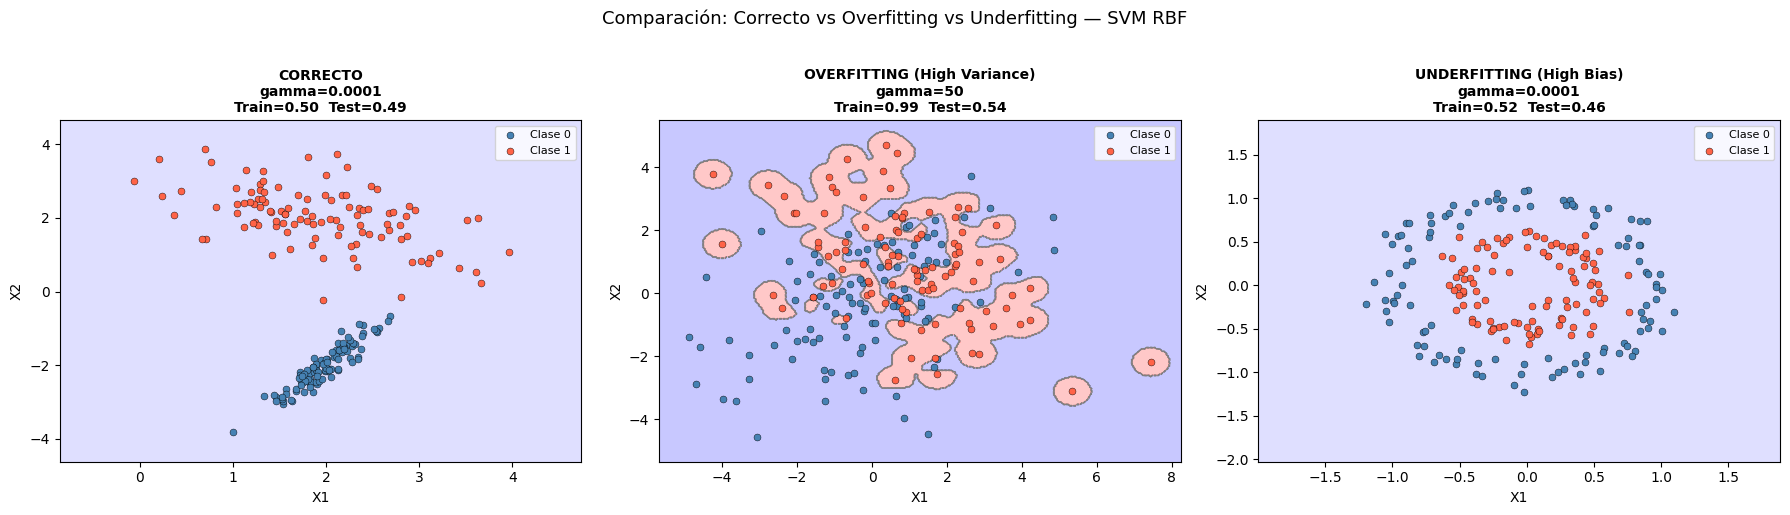

In [53]:
# ── Gráfico comparativo: Correcto vs Overfitting vs Underfitting ──────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_boundary(
    clf_ok, scaler_ok, X_ok_tr, y_ok_tr,
    f'CORRECTO\ngamma={mejor_gamma:.4f}\nTrain={s_ok_tr:.2f}  Test={s_ok_te:.2f}',
    axes[0]
)

plot_boundary(
    clf_ov, scaler_ov, X_ov_tr, y_ov_tr,
    f'OVERFITTING (High Variance)\ngamma={gamma_alto:.0f}\nTrain={s_ov_tr:.2f}  Test={s_ov_te:.2f}',
    axes[1]
)

plot_boundary(
    clf_uf, scaler_uf, X_uf_tr, y_uf_tr,
    f'UNDERFITTING (High Bias)\ngamma={gamma_bajo}\nTrain={s_uf_tr:.2f}  Test={s_uf_te:.2f}',
    axes[2]
)

plt.suptitle('Comparación: Correcto vs Overfitting vs Underfitting — SVM RBF',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Curvas de aprendizaje comparativas de los 3 escenarios 


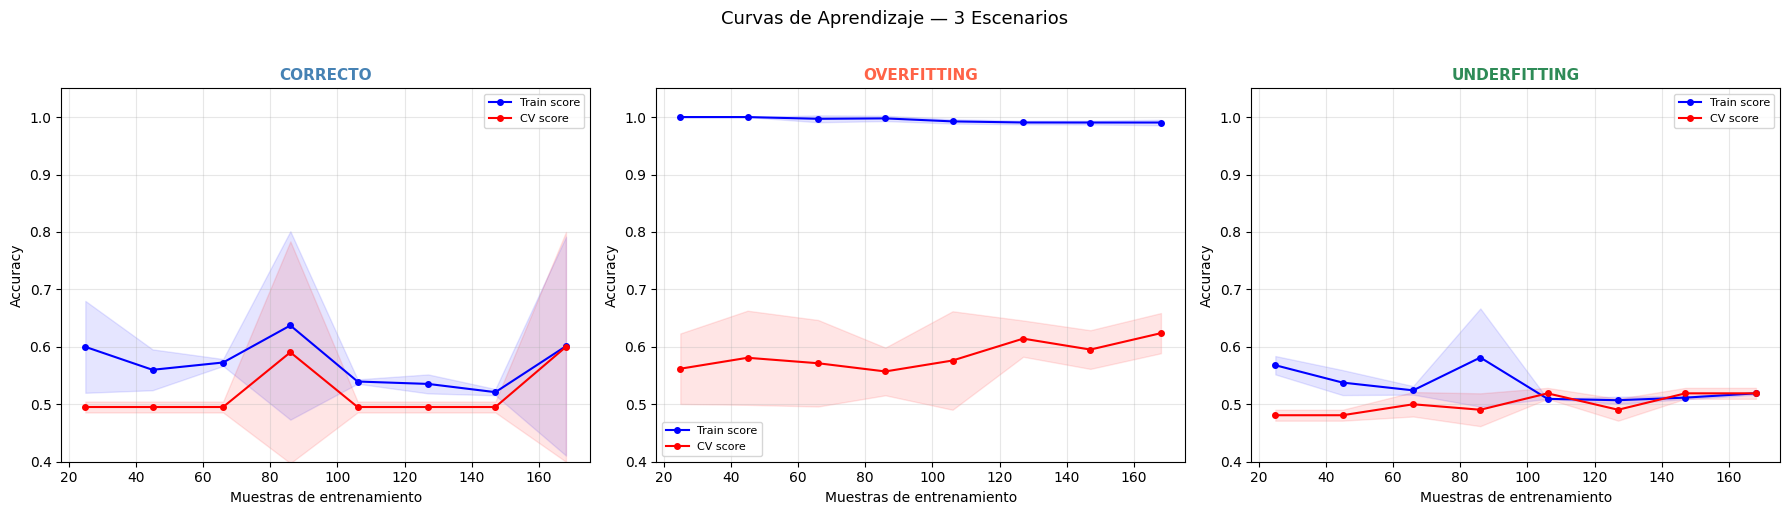

In [54]:
# ── Curvas de aprendizaje comparativas de los 3 escenarios ───────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

configs = [
    (SVC(kernel='rbf', gamma=mejor_gamma, C=1.0),
     StandardScaler().fit(X_ok_tr), X_ok_tr, y_ok_tr,
     'CORRECTO', 'steelblue'),
    (SVC(kernel='rbf', gamma=gamma_alto, C=10.0),
     StandardScaler().fit(X_ov_tr), X_ov_tr, y_ov_tr,
     'OVERFITTING', 'tomato'),
    (SVC(kernel='rbf', gamma=gamma_bajo, C=1.0),
     StandardScaler().fit(X_uf_tr), X_uf_tr, y_uf_tr,
     'UNDERFITTING', 'seagreen'),
]

for ax, (clf_c, sc_c, Xtr, ytr, titulo, color) in zip(axes, configs):
    Xtr_s = sc_c.transform(Xtr)
    sizes, tr_sc, cv_sc = learning_curve(
        clf_c, Xtr_s, ytr, cv=5,
        train_sizes=np.linspace(0.15, 1.0, 8),
        scoring='accuracy'
    )
    tr_m = tr_sc.mean(axis=1) ; tr_s = tr_sc.std(axis=1)
    cv_m = cv_sc.mean(axis=1) ; cv_s = cv_sc.std(axis=1)

    ax.fill_between(sizes, tr_m - tr_s, tr_m + tr_s, alpha=0.1, color='blue')
    ax.fill_between(sizes, cv_m - cv_s, cv_m + cv_s, alpha=0.1, color='red')
    ax.plot(sizes, tr_m, 'b-o', ms=4, label='Train score')
    ax.plot(sizes, cv_m, 'r-o', ms=4, label='CV score')
    ax.set_title(titulo, fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel('Muestras de entrenamiento')
    ax.set_ylabel('Accuracy')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.4, 1.05)

plt.suptitle('Curvas de Aprendizaje — 3 Escenarios', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Analisis de resultados
 
# Punto 3.1 — Curva score vs gamma
 - Para gamma pequeno: train score y CV score son similares pero bajos (underfitting)
 - Para gamma grande: train score sube a 1.0 pero CV score cae (overfitting)
 - El mejor gamma esta en el pico de la curva de CV
 
# Punto 3.2 — Curvas de aprendizaje
 - Si las curvas train y CV convergen en valor alto: modelo bien ajustado
 - Si hay gran brecha: overfitting (necesita mas datos o regularizacion)
 - GridSearch confirma o mejora el gamma encontrado manualmente
 
# Punto 3.3 — Overfitting y Underfitting
 - OVERFITTING: train accuracy ~1.0, test accuracy baja
   Causa: gamma muy alto, el modelo 'memoriza' el ruido del dataset solapado
 - UNDERFITTING: ambos accuracy bajos
   Causa: gamma muy bajo, la frontera de decision es casi lineal
   y no puede capturar la estructura circular del dataset
 - CORRECTO: ambos accuracy altos y similares
